In [77]:
# Importando librearias necesarias:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import plot_histogram
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np

# Ejercicio 1

In [130]:
#Creamos nuestra función QFTInversa
def miQFTInv(n): 
    rqft_circuit = QuantumCircuit(n)
    for i in reversed(range(n//2)):
        rqft_circuit.swap(i, n-i-1)

    rqft_circuit.barrier()

    for j in range(n):                  # considerar el orden invertido de qubits en Qiskit
        for k in range(j):
            rqft_circuit.cp(-np.pi / 2**(j-k), k, j)
        rqft_circuit.h(j)
        rqft_circuit.barrier()
        
        

    return rqft_circuit
    
    

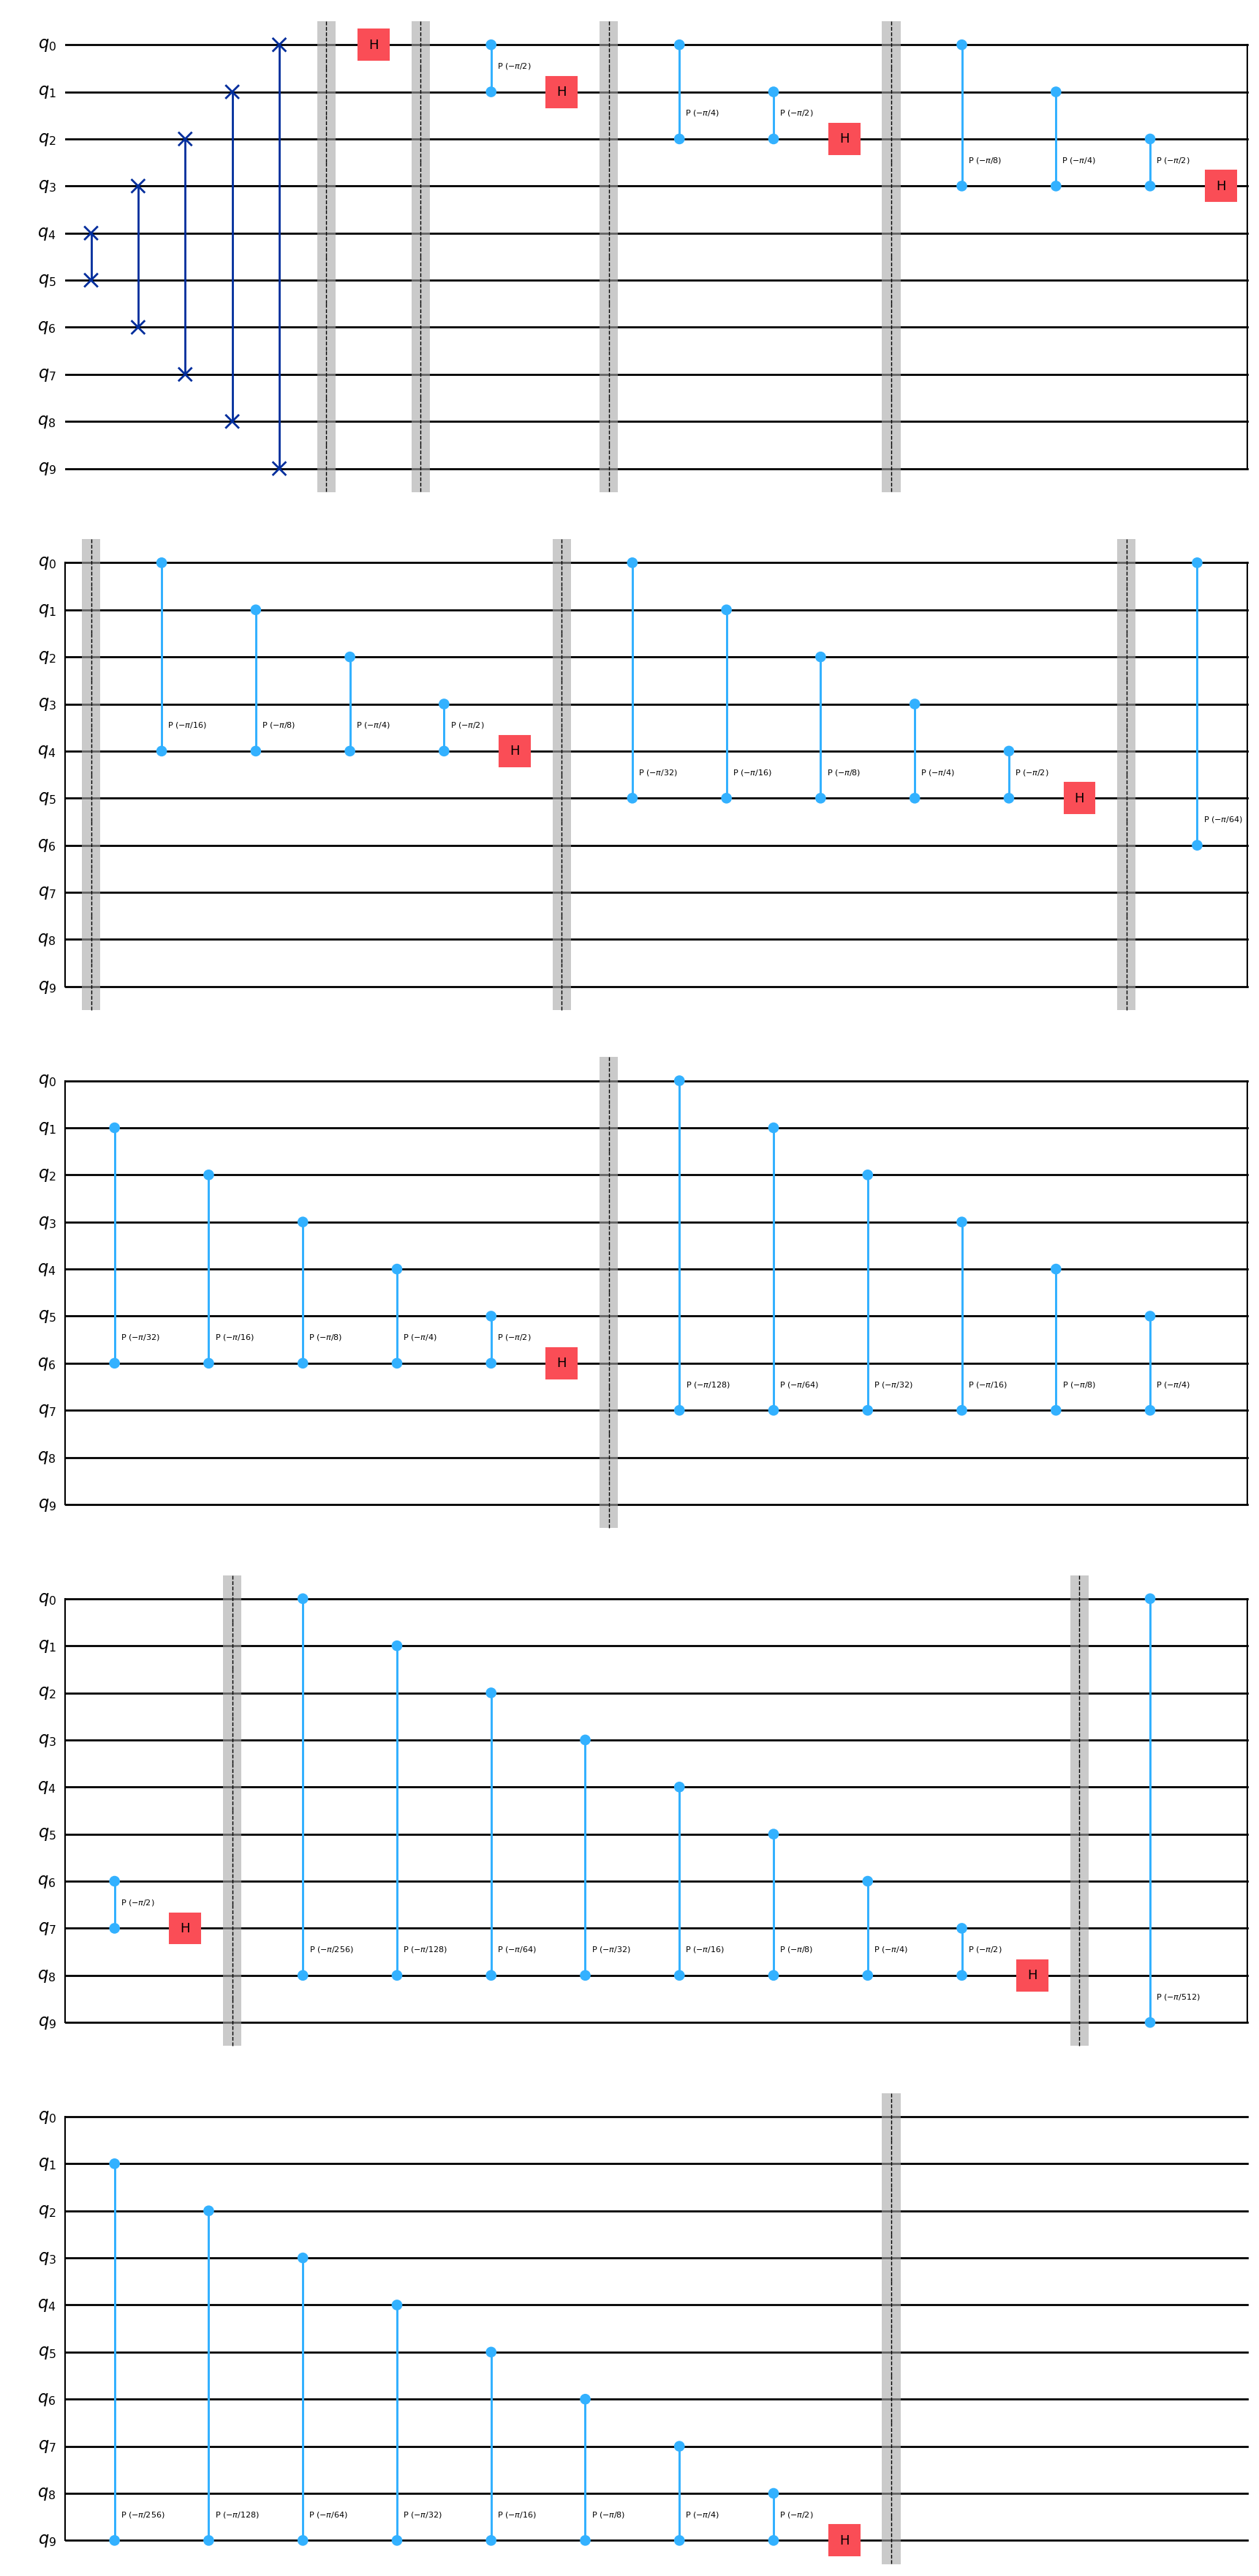

In [131]:
miQFTInv(10).draw('mpl') ##Dibujamos circuito para 10 qbits

In [65]:
##Creamos nuestra función que prepara el estado base

def createBaseState(circuit, valor, n):
    binario = format(valor, f"0{n}b")

    for i, bit in enumerate(reversed(binario)):

        if bit == "1":

            circuit.x(i)

    return binario

In [132]:
def testQFTI(n):
    
    for valor in range(2 ** n):

        qc = QuantumCircuit(n,n)

        estado_binario = createBaseState(qc, valor, n)

        print(f"------------- Para n = {n} y estado binario: {estado_binario}--------")

        print("➤ Estado inicial en forma de ket:")
        pre_circ = Statevector(qc)   # Estado incial
        display(pre_circ.draw('latex'))

        qc.barrier()

        qfti = miQFTInv(n)
        qfti.draw('mpl')
        matrix = Operator(miQFTInv(n))
        mi_qfti = UnitaryGate(matrix, 'mi_qfti') #Compuerta QFTInv personalizada

        qc.append(mi_qfti, list(range(n)))

        qc.barrier()


        qft_qc = QFT(n, insert_barriers=True).decompose()
        qc.compose(qft_qc, qubits=list(range(n)), inplace=True)

        print("➤ Estado final en forma de ket:")
        res_circ = Statevector(qc)   # Estado final
        display(res_circ.draw('latex'))
        

        qc.barrier()


        qc.measure(list(range(n)),list(range(n)))  # medir los n qubits en los n bits clásicos

        
        simulator_basic = BasicSimulator()

        job = simulator_basic.run(qc, shots=5000)
        result = job.result()
        counts = result.get_counts()
        print("\n")
        print("---------------------")
        
        

       
        

     




In [133]:
testQFTI(4)

------------- Para n = 4 y estado binario: 0000--------
➤ Estado inicial en forma de ket:


<IPython.core.display.Latex object>

➤ Estado final en forma de ket:


/var/folders/bw/fvbxrfwn17sgmz7pxt59f_400000gn/T/ipykernel_1543/1392381423.py:27: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_qc = QFT(n, insert_barriers=True).decompose()


<IPython.core.display.Latex object>

...



---------------------
------------- Para n = 4 y estado binario: 1111--------
➤ Estado inicial en forma de ket:


<IPython.core.display.Latex object>

➤ Estado final en forma de ket:


<IPython.core.display.Latex object>



---------------------


# Ejercicio 2